<a href="https://colab.research.google.com/github/hadasecohen/streaming-vae-anomaly-detection/blob/main/notebooks/cases/case01_clean_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case 1

# Clean-data false-positive baseline, and how dataset scale affects it

## Purpose of this notebook

This notebook serves two purposes the thesis-replication depends on:

> 1. **The baseline comparison** (~ Fig 4.1, 4.2, Table 4.1): with no injected anomalies, every predicted anomaly is a false positive — so this directly measures false-positive calibration for four architectures (plain MLP-VAE, MLP-VAE-Cyclic, LSTM-VAE, Transformer-VAE).
> 2. **Why dataset scale matters for that comparison**: the same four-architecture suite run at three different dataset scales (mini_28pct, mini_50pct, full-scale) shows that **each architecture's own false-positive rate — not just the ranking between architectures — shifts with how much warmup data it gets.** This isn't a hypothetical concern: it was discovered while comparing datasets of lower scales.

---

For the complete experiment definitions, consult the thesis sections associated with Fig 4.1, Fig 4.2, and Table 4.1, together with the YAML configuration files used by this suite.

## What is being compared?

This notebook runs **one suite** (`case01_clean_baseline_suite.yaml`) at **three dataset scales** — `DATA_SOURCE = "mini_28pct"`, `"mini_50pct"`, and `"full_split_files"` — and compares each architecture's own results across scales:

| Variant | Architecture | Meaning |
|---|---|---|
| **MLP-VAE** | Feed-forward VAE, plain (no cyclic reconstruction) | thesis_code's baseline MLP. |
| **MLP-VAE-Cyclic** | Feed-forward VAE, cyclic time features reconstructed | The thesis found this stays calibrated from the very first test-stream step. |
| **LSTM-VAE** | Recurrent VAE | Sits between the MLP and Transformer variants in capacity. |
| **Transformer-VAE** | Attention-based VAE | The thesis found this overfits the warmup window and produces an early false-positive burst before its rolling threshold adapts. |

All four use the same base configuration, the same anomaly type (Clean), and the same evaluation procedure at each scale. The intended comparison is therefore **how each architecture's own false-positive calibration changes as warmup data grows** — not which architecture "wins" at a given scale.

## Finding being illustrated

Looking at each architecture's **own** false-positive rate as warmup data grows from mini_28pct (~12-year warmup) through mini_50pct (~17-year warmup) to full-scale (~34.5-year warmup, matching thesis_code's own experiment exactly):

- **Transformer-VAE's FPR rises** with more warmup data — its early-miscalibration-burst effect (attributed to overfitting the warmup window) needs enough warmup data to actually manifest. At the shortest scale there isn't enough data for it to overfit, so the burst that drives its FPR up barely shows; at full scale it does, and Transformer-VAE ends up the *least* calibrated of the four — matching the thesis.
- **MLP-VAE-Cyclic's FPR falls (or stays low)** with more warmup data — consistent with the thesis's finding that it stays calibrated from the first test-stream step onward, regardless of how much warmup it was given.
- **MLP-VAE** sits in between, with comparatively small movement across scales.
- **LSTM-VAE has** the widest run-to-run variance of the four architectures. Across seven otherwise-identical LSTM-VAE runs on the mini_50pct clean baseline, false-positive rate swung from 22.4% to 89.6% by seed alone.

Exact FP counts vary run to run (seed, real hardware nondeterminism), but each architecture's *direction of movement* across scales should reproduce: Transformer-VAE trending worse, MLP-VAE-Cyclic trending better or flat, as warmup data grows.

---

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run the four-architecture clean-baseline suite on the mini_28pct dataset.
4. Run the same suite on the mini_50pct dataset.
5. Run the same suite on the full-scale dataset.
6. Compare each architecture's own false-positive rate across the three scales.

### Expected runtime

The two mini runs each finish in about a minute. The full-scale run takes roughly 15–30 minutes (four architectures training on ~34.5 years of warmup data) — total runtime for this notebook is dominated by the full-scale step.

# Run Case

### Check GPU availability

In [ ]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


Environment check
-----------------
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


### Import and/or load Repo

In [ ]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(
            ["git", "clone", REPO_URL, str(REPO_DIR)],
            check=True,
        )

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("scripts/run_all_trials.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


Working directory: /content/repo
Installing the project dependencies...
env: MPLBACKEND=Agg
Setup complete.


### Step 1 — Configure both dataset-scale runs

In [ ]:
import os
import yaml

CASE_ID = "case01_clean_baseline"
SESSION_ROOT = "runs/trials_suite/case01_clean_baseline"


_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # See case01_clean_baseline.ipynb's Step 1 cell for why this resolves to
    # absolute paths rather than leaving config_layers entries relative —
    # in short, the resolved copy is written deep under OUTPUT_DIR, and a
    # relative ../../modules/... path only works from notebooks/cases/.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

_DATA_SOURCE_LAYERS = {
    "mini_50pct": "../../modules/data_source/mini_50pct_clean.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_clean.yaml",
    "full_single_file": "../../modules/data_source/full_single_file_clean.yaml",
    "full_split_files": None,   # anom_types/clean.yaml's own default — no extra layer needed
}
_SESSION_LABELS = {"mini_50pct": "mini_50pct", "mini_28pct": "mini_28pct", "full_single_file": "full_single", "full_split_files": "full"}

def build_resolved_suite(data_source):
    """Write a resolved copy of case01's suite for one DATA_SOURCE.
    Returns (session_dir, output_dir, suite_path)."""
    label = _SESSION_LABELS[data_source]
    session_dir = f"{SESSION_ROOT}_{label}"
    output_dir = f"{session_dir}/{CASE_ID}"

    with open(_suite_source_path) as f:
        suite = yaml.safe_load(f)
    suite["base_config"] = _resolve(suite["base_config"])
    layer = _DATA_SOURCE_LAYERS[data_source]
    for run in suite["runs"]:
        layers = [_resolve(p) for p in run["config_layers"]]
        if layer:
            layers.append(_resolve(layer))
        run["config_layers"] = layers

    os.makedirs(output_dir, exist_ok=True)
    suite_path = f"{output_dir}/{CASE_ID}_suite_resolved.yaml"
    with open(suite_path, "w") as f:
        yaml.safe_dump(suite, f, sort_keys=False)
    return session_dir, output_dir, suite_path

MINI28_SESSION_DIR, MINI28_OUTPUT_DIR, MINI28_SUITE_PATH = build_resolved_suite("mini_28pct")
MINI50_SESSION_DIR, MINI50_OUTPUT_DIR, MINI50_SUITE_PATH = build_resolved_suite("mini_50pct")
FULL_SESSION_DIR, FULL_OUTPUT_DIR, FULL_SUITE_PATH = build_resolved_suite("full_split_files")

print("mini_28pct dataset run -> ", MINI28_OUTPUT_DIR)
print("mini_50pct dataset run -> ", MINI50_OUTPUT_DIR)
print("full-scale run         -> ", FULL_OUTPUT_DIR)


mini_28pct dataset run ->  runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline
mini_50pct dataset run ->  runs/trials_suite/case01_clean_baseline_mini_50pct/case01_clean_baseline
full-scale run         ->  runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline


#### Configuration file

All three runs come from the same source file:

```text
notebooks/cases/case01_clean_baseline_suite.yaml
```

When the `DATA_SOURCE` value is `"full_split_files"`, no additional dataset configuration is appended, since full-scale is already the default at `modules/anom_types/clean.yaml`'s own default. `"mini_50pct"` appends `modules/data_source/mini_50pct_clean.yaml`, and `"mini_28pct"` appends `modules/data_source/mini_28pct_clean.yaml`. Each resolved copy is written under its own `OUTPUT_DIR` (`runs/trials_suite...`).

All three dataset-scale modes read real, non-synthetic ERA5 data at the same warmup/test split point (1974-06-23) — only the amount of warmup/test data around that point differs. See `DATA_LICENSE.md` for exact row counts.

### Step 2a — Run on the mini 28% dataset

### Command:

**If this fails with `ModuleNotFoundError: No module named 'src.utils'`**, please [open a GitHub issue](https://github.com/hadasecohen/streaming-vae-anomaly-detection/issues/new) with the full traceback rather than trying to fix it locally — it means the compiled `src/` no longer matches Colab's Python version and needs to be recompiled and re-released.

In [ ]:
!python scripts/run_all_trials.py {MINI28_SUITE_PATH} \
    --session {MINI28_SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/trials_suite/case01_clean_baseline_mini_28pct/suite.log
[suite] suite   : /content/repo/runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /content/repo/runs/trials_suite/case01_clean_baseline_mini_28pct
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : scripts.trial.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
[suite] --skip-existing: completed runs will b

### Step 2b — Run on the mini 50% dataset

### Command:

In [ ]:
!python scripts/run_all_trials.py {MINI50_SUITE_PATH} \
    --session {MINI50_SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/trials_suite/case01_clean_baseline_mini_50pct/suite.log
[suite] suite   : /content/repo/runs/trials_suite/case01_clean_baseline_mini_50pct/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /content/repo/runs/trials_suite/case01_clean_baseline_mini_50pct
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : scripts.trial.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
[suite] --skip-existing: completed runs will b

### Step 2c — Run on the full-scale dataset

Same four architectures, same suite, same warmup/test boundary — only the amount of real data on each side of that boundary differs from Step 2a and 2b. This is the slow part of the notebook (see Expected runtime above).

### Command:

In [6]:
!python scripts/run_all_trials.py {FULL_SUITE_PATH} \
    --session {FULL_SESSION_DIR} --skip-existing

[suite] log     : /content/repo/runs/trials_suite/case01_clean_baseline_full/suite.log
[suite] suite   : /content/repo/runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/case01_clean_baseline_suite_resolved.yaml
[suite] session : /content/repo/runs/trials_suite/case01_clean_baseline_full
[suite] base cfg: /content/repo/modules/era5_common.yaml
[suite] module  : scripts.trial.run_trial
[suite] GPUs    : [0]  (1 slot(s))
[suite] 4 run(s) planned:
  [  1] MLP_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  2] MLP_Cyclic_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  3] LSTM_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
  [  4] TF_VAE_Clean  [case01_clean_baseline/case01_clean_baseline_suite_resolved]  (module: scripts.trial.run_trial)
[suite] --skip-existing: completed runs will be skipped
[suite] 

### Step 3 — Build a common comparison for each scale

#### The next command reads the predictions from every run and produces:

- a common performance table
- anomaly-score histograms (TN and FP only)
- an FPR comparison across variants
- seed-stability diagnostics, where applicable.

These outputs are saved under `OUTPUT_DIR/cross_compare/`.

### Command:

In [7]:
!python scripts/cross_compare.py {MINI28_OUTPUT_DIR}
!python scripts/cross_compare.py {MINI50_OUTPUT_DIR}
!python scripts/cross_compare.py {FULL_OUTPUT_DIR}

[cross] session : runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline
[cross] output  : runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline/cross_compare
[cross] 4 run(s) found:
  LSTM_Clean_LSTM                                     arch=LSTM  anomaly=Clean  cyclic=False  mode=window
  MLP_Clean_MLP                                       arch=MLP  anomaly=Clean  cyclic=False  mode=window
  MLP_Cyclic_Clean_MLP_Cyclic                         arch=MLP_Cyclic  anomaly=Clean  cyclic=False  mode=window
  TF_VAE_Clean_TF_VAE                                 arch=TF_VAE  anomaly=Clean  cyclic=False  mode=window

[cross] Loading run data ...
  LSTM_Clean_LSTM ... ok
  MLP_Clean_MLP ... ok
  MLP_Cyclic_Clean_MLP_Cyclic ... ok
  TF_VAE_Clean_TF_VAE ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Clean anomalies ════════════════════════════════════════════════════════════════════════════════════════════

### Step 4 — Quantitative Results

### Command:

In [8]:
import pandas as pd
from IPython.display import display

def load_fpr(output_dir):
    perf = pd.read_csv(f"{output_dir}/cross_compare/performance_table.csv")
    perf["fpr_pct"] = 100 * perf["fp"] / (perf["fp"] + perf["tn"])
    return perf.set_index("arch")[["fp", "tn", "fpr_pct"]]

mini28_fpr = load_fpr(MINI28_OUTPUT_DIR).add_prefix("mini28_")
mini_fpr = load_fpr(MINI50_OUTPUT_DIR).add_prefix("mini50_")
full_fpr = load_fpr(FULL_OUTPUT_DIR).add_prefix("full_")

# One row per architecture, scales left-to-right in increasing warmup-data order —
# each row is that architecture's own FPR trend as warmup data grows.
comparison = mini28_fpr.join(mini_fpr).join(full_fpr)
comparison["trend"] = comparison["full_fpr_pct"] - comparison["mini28_fpr_pct"]
comparison["direction"] = comparison["trend"].apply(
    lambda d: "rising" if d > 0.5 else ("falling" if d < -0.5 else "flat")
)

print("Each architecture's own FPR (%) at increasing warmup-data scale — read each row left to right:")
display(
    comparison[[
        "mini28_fpr_pct", "mini50_fpr_pct", "full_fpr_pct", "trend", "direction",
    ]].rename(columns={
        "mini28_fpr_pct": "FPR % (mini_28pct)",
        "mini50_fpr_pct": "FPR % (mini_50pct)",
        "full_fpr_pct": "FPR % (full-scale)",
        "trend": "full - mini28 (pp)",
        "direction": "trend",
    }).sort_values("full - mini28 (pp)")
)

Each architecture's own FPR (%) at increasing warmup-data scale — read each row left to right:


,FPR % (mini_28pct),FPR % (mini_50pct),FPR % (full-scale),full - mini28 (pp),trend
arch,,,,,
MLP_Cyclic,7.813571,1.080737,1.090928,-6.722643,falling
MLP,1.119488,1.451579,1.472224,0.352735,flat
TF_VAE,0.822481,15.903793,5.258698,4.436217,rising
LSTM,0.822481,15.660097,8.610920,7.788439,rising


#### Compare each architecture's FPR across scales

In the cell above all three `performance_table.csv` files are used to compute the false-positive rate for each architecture at each scale, laid out as one row per architecture and one column per scale — so each architecture's own trend across scales reads directly left to right.

#### Main takeaway

Each architecture's FPR trend above (rising, falling, or flat as warmup data grows) is the finding this notebook exists to show — **the same architecture can look differently calibrated depending on how much warmup data it's evaluated with, independent of how it compares to any other architecture.** Transformer-VAE is expected to trend upward (worse) and MLP-VAE-Cyclic to trend flat-or-downward (stable or better) as warmup data grows from mini_28pct to full-scale — this is why the default `DATA_SOURCE = "full_split_files"` matters: evaluating any one architecture at mini scale can understate (or overstate) its true full-scale false-positive rate.

It is cheaper to iterate on a mini dataset, but architecture, scale and seed may impact calibration stability.

### Step 5 — Qualitative support (Plots)

### Command:

Saved → runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline/rolling_metrics.png
Saved → runs/trials_suite/case01_clean_baseline_mini_28pct/case01_clean_baseline/rolling_metrics.txt
Saved → runs/trials_suite/case01_clean_baseline_mini_50pct/case01_clean_baseline/rolling_metrics.png
Saved → runs/trials_suite/case01_clean_baseline_mini_50pct/case01_clean_baseline/rolling_metrics.txt
Saved → runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/rolling_metrics.png
Saved → runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/rolling_metrics.txt
mini_28pct dataset:


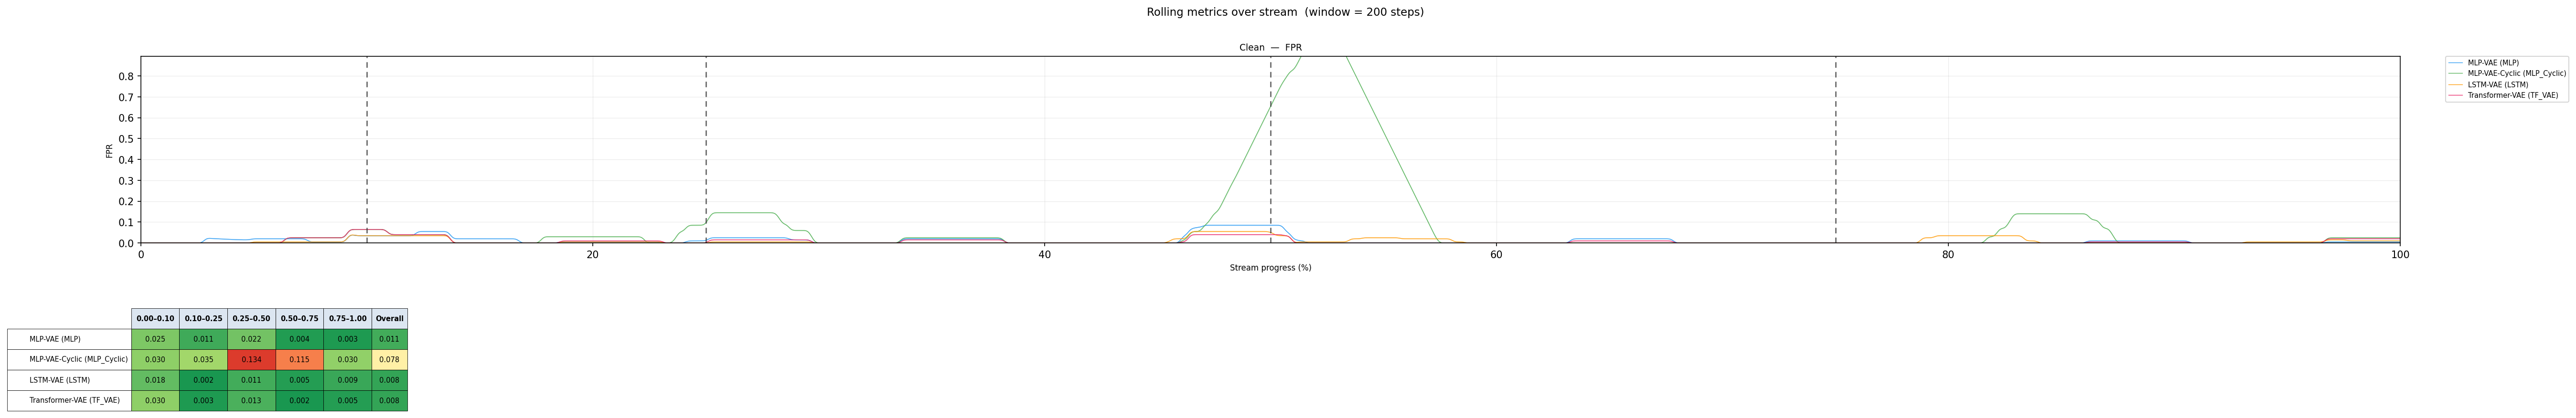

mini_50pct dataset:


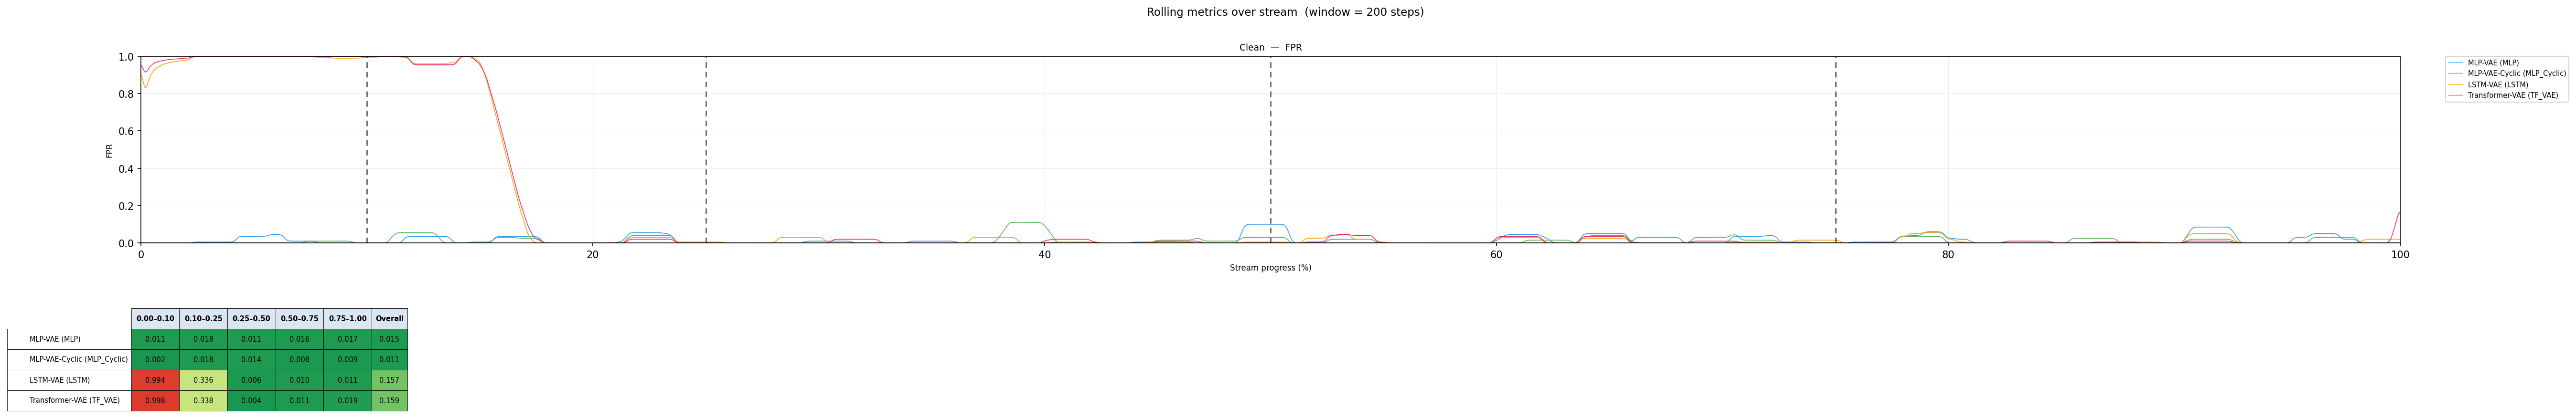

Full-scale dataset:


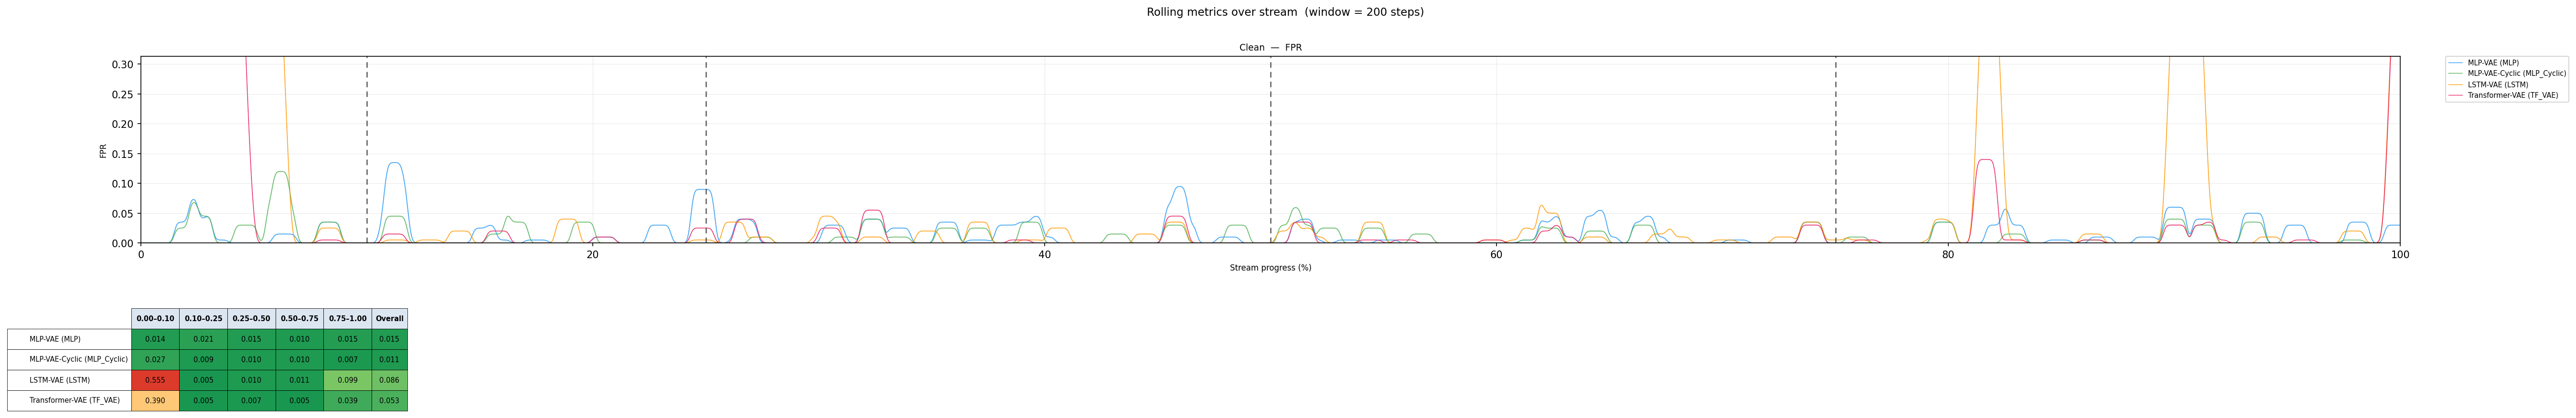

In [9]:
!python scripts/plot_fpr_over_time.py {MINI28_OUTPUT_DIR}
!python scripts/plot_fpr_over_time.py {MINI50_OUTPUT_DIR}
!python scripts/plot_fpr_over_time.py {FULL_OUTPUT_DIR}

from IPython.display import Image, display

print("mini_28pct dataset:")
display(Image(filename=f"{MINI28_OUTPUT_DIR}/rolling_metrics.png"))

print("mini_50pct dataset:")
display(Image(filename=f"{MINI50_OUTPUT_DIR}/rolling_metrics.png"))

print("Full-scale dataset:")
display(Image(filename=f"{FULL_OUTPUT_DIR}/rolling_metrics.png"))

#### Plot rolling-FPR curves for all three scales

The scalar FPR values above are single numbers for the whole test stream. Plotting the rolling FPR over time for all three scales side by side shows *when* each architecture's divergence happens as warmup data grows — in particular, whether Transformer-VAE's early-burst pattern is visible at the shortest scale at all, and how it builds up toward full scale.

### Step 6 — Latent space (full-scale, last 10 years)

A 3D UMAP projection of each architecture's latent space on the full-scale run, restricted to data from 2016-01-01 onward (the full run spans decades, and UMAP fitting time grows with sample count — a fixed ~10-year window keeps this fast while still showing the model's recent behaviour). Useful for seeing whether the model's latent representation organizes by the seasonal structure the data has, and, since this notebook's baseline is clean data, whether any false positives cluster in a distinct region rather than scattering evenly. Only the month-colored plot is shown below (per architecture) to keep this section manageable — hour-of-day and day-of-year are also generated by the command if you want to check them yourself (hour-of-day carries no information here anyway, since this run uses stride=24 and every sample lands at the same hour).

### Command:

In [14]:
!python scripts/plot_latent_umap.py {FULL_SESSION_DIR} --recursive --from-date 2016-01-01

Found 4 trial directories under runs/trials_suite/case01_clean_baseline_full

────────────────────────────────────────────────────────────
[1/4] runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/case01_clean_baseline_suite_resolved/Clean/LSTM/baseline_LSTM/8d212557884e_seed_49
Loaded latent_mu: (18883, 24)
Date filter: 3716 / 18883 samples kept (2016-01-01 → 2026-03-04)
Fitting UMAP (n_neighbors=150, min_dist=0.1, n=3716, d=24) …
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
UMAP done.
Corr with linear time:  U1=+0.038  U2=-0.058  U3=+0.018
Subsampled to 3716 display points
Saved → runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/case01_clean_baseline_suite_resolved/Clean/LSTM/baseline_LSTM/8d212557884e_seed_49/latent_umap_month.html
Saved → runs/trials_suite/case01_clean_baseline_full/case01_clean_baseline/case01_clean_baseline_suit

Each plot is saved as both a static .png snapshot (shown below — renders everywhere) and an interactive .html (rotate/zoom/hover, shown after — only in Colab, since GitHub's and VS Code's notebook previews block the external script it depends on).

Found 4 trial directories under runs/trials_suite/case01_clean_baseline_full
=== LSTM ===


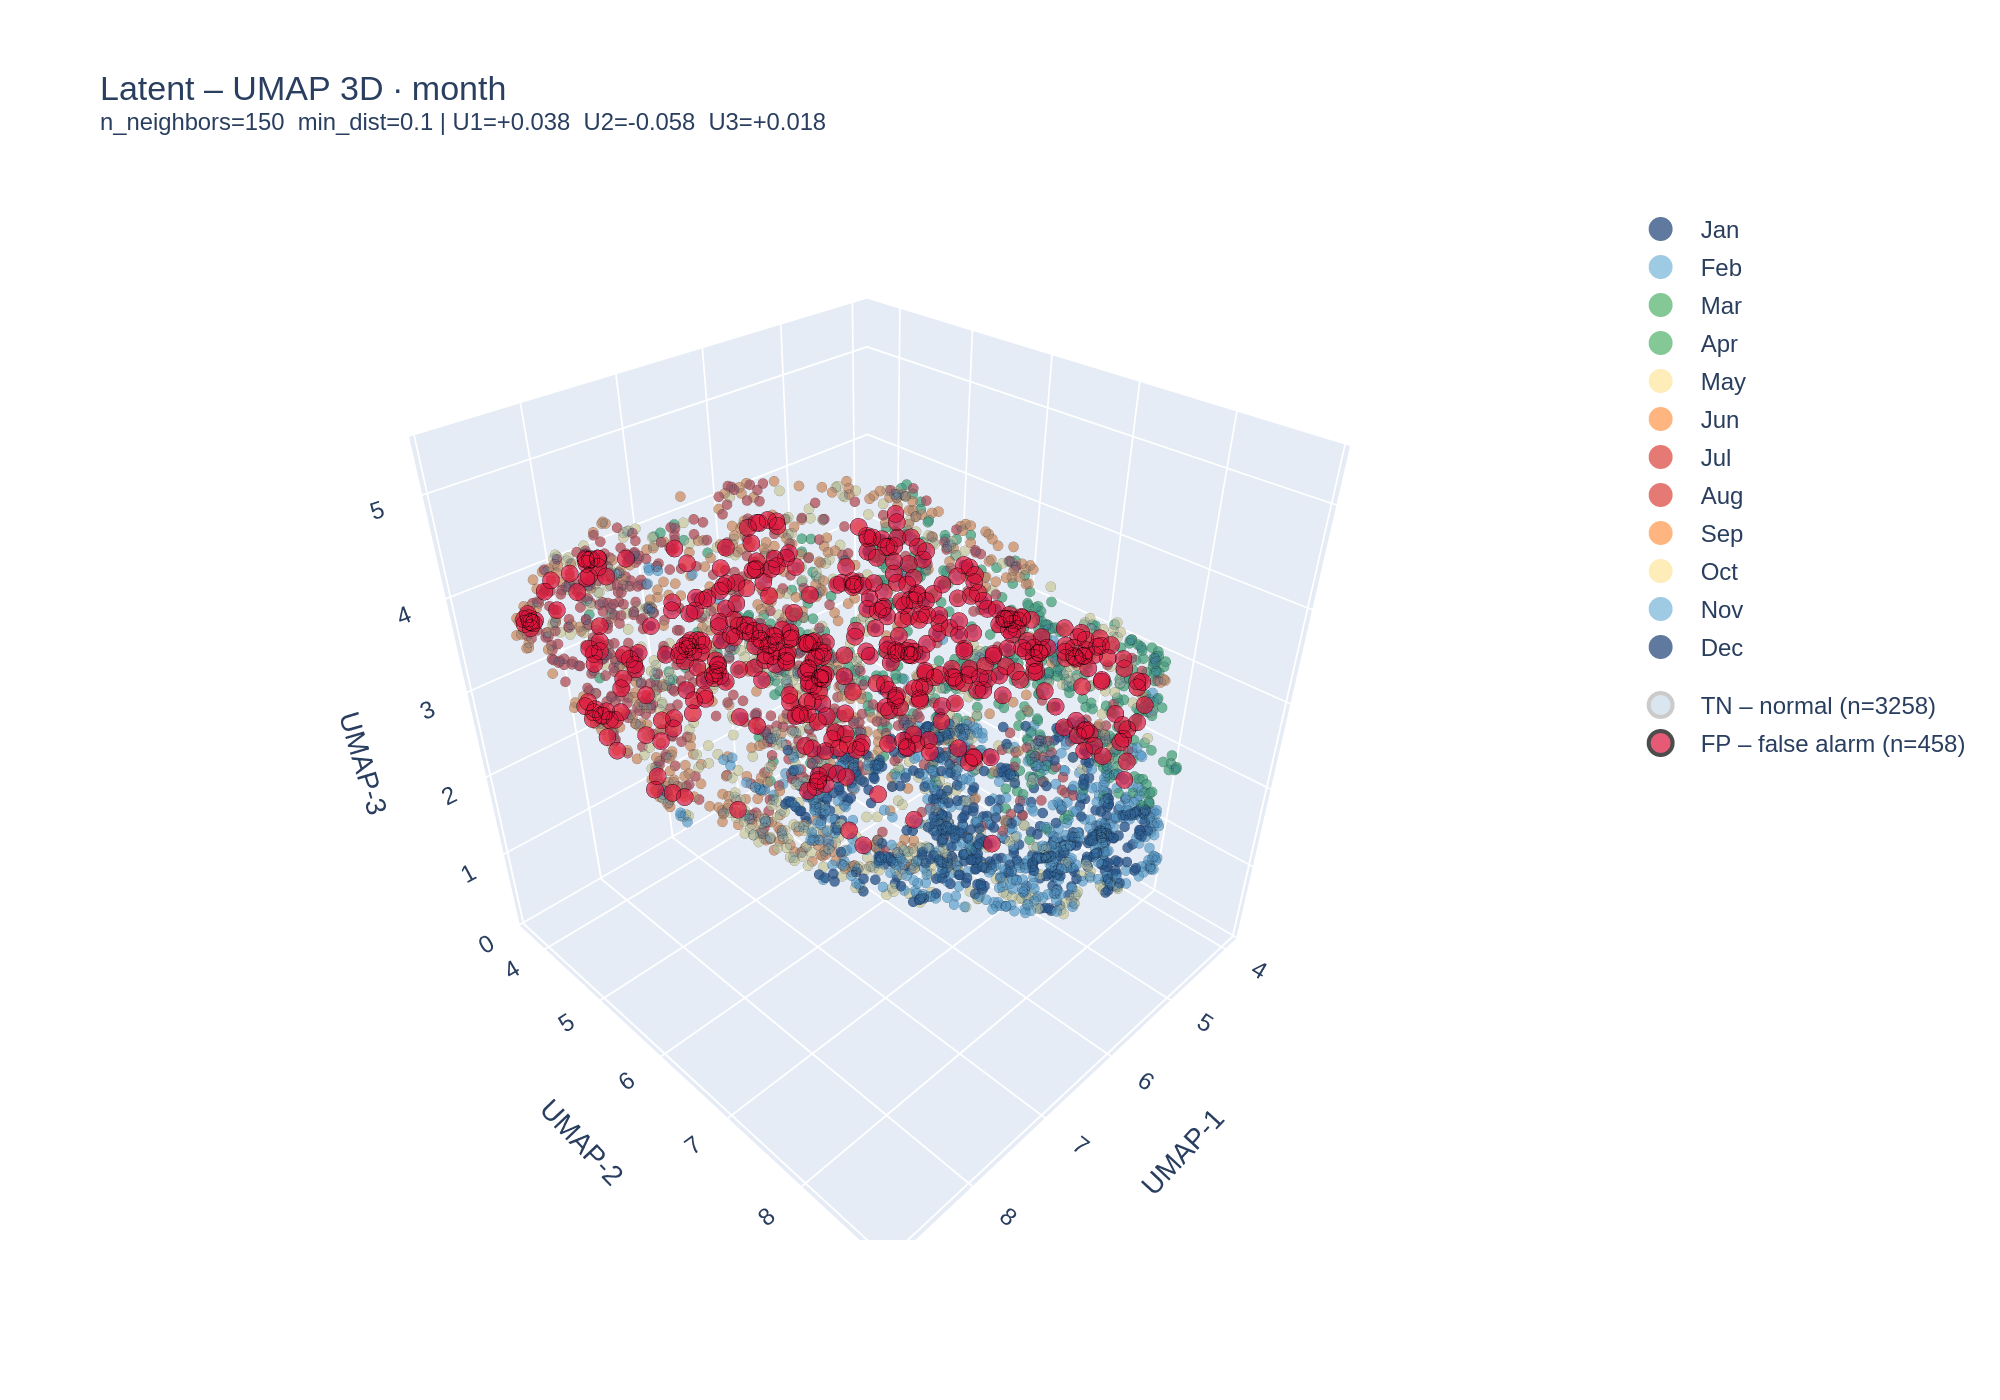

=== MLP ===


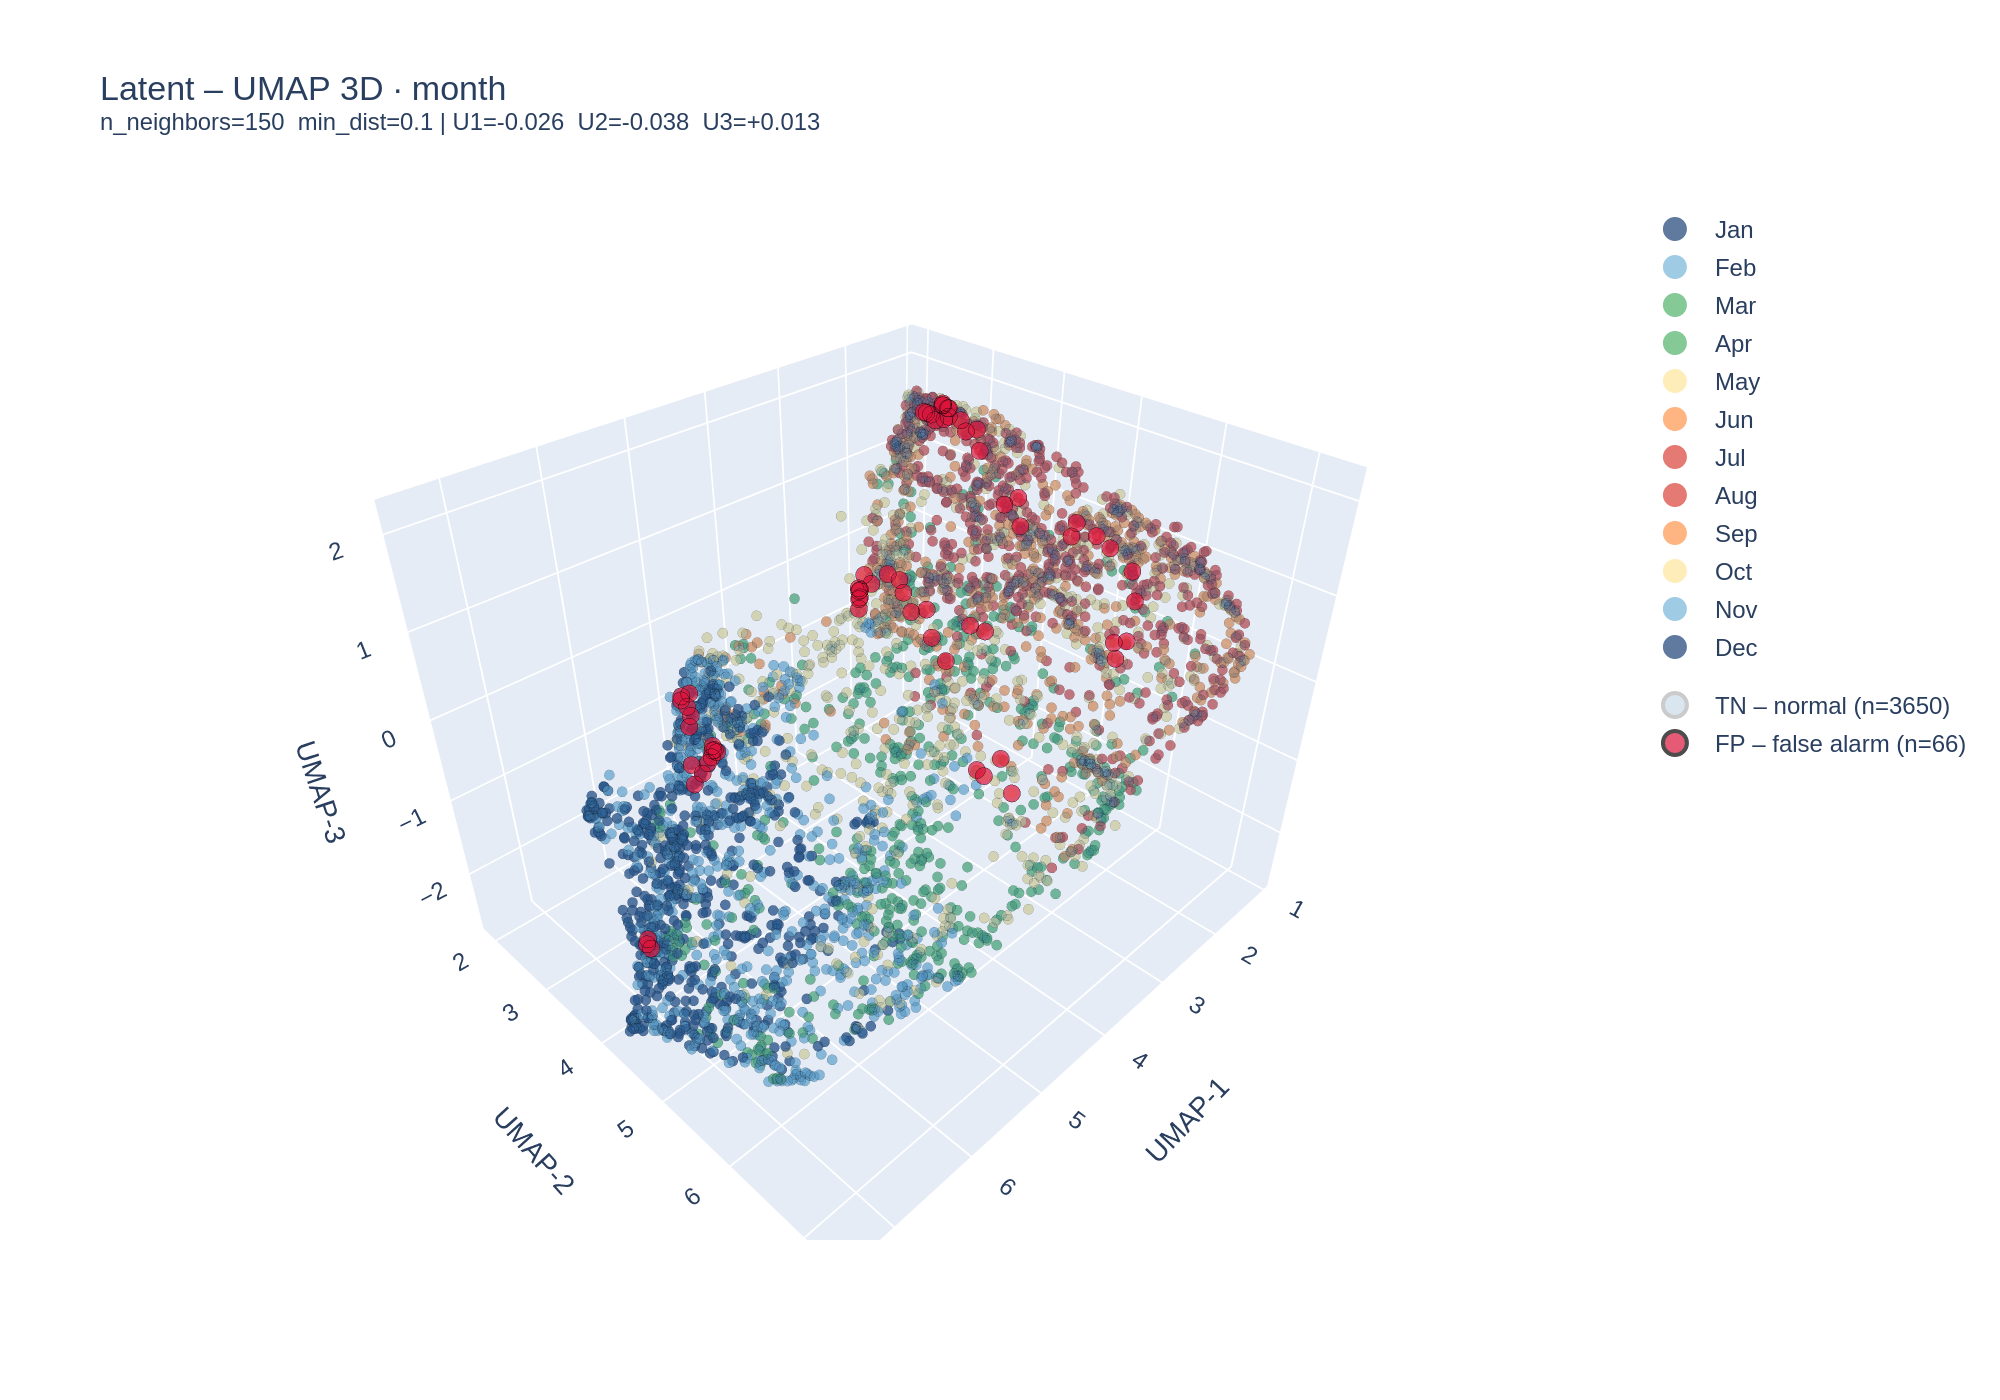

=== MLP_Cyclic ===


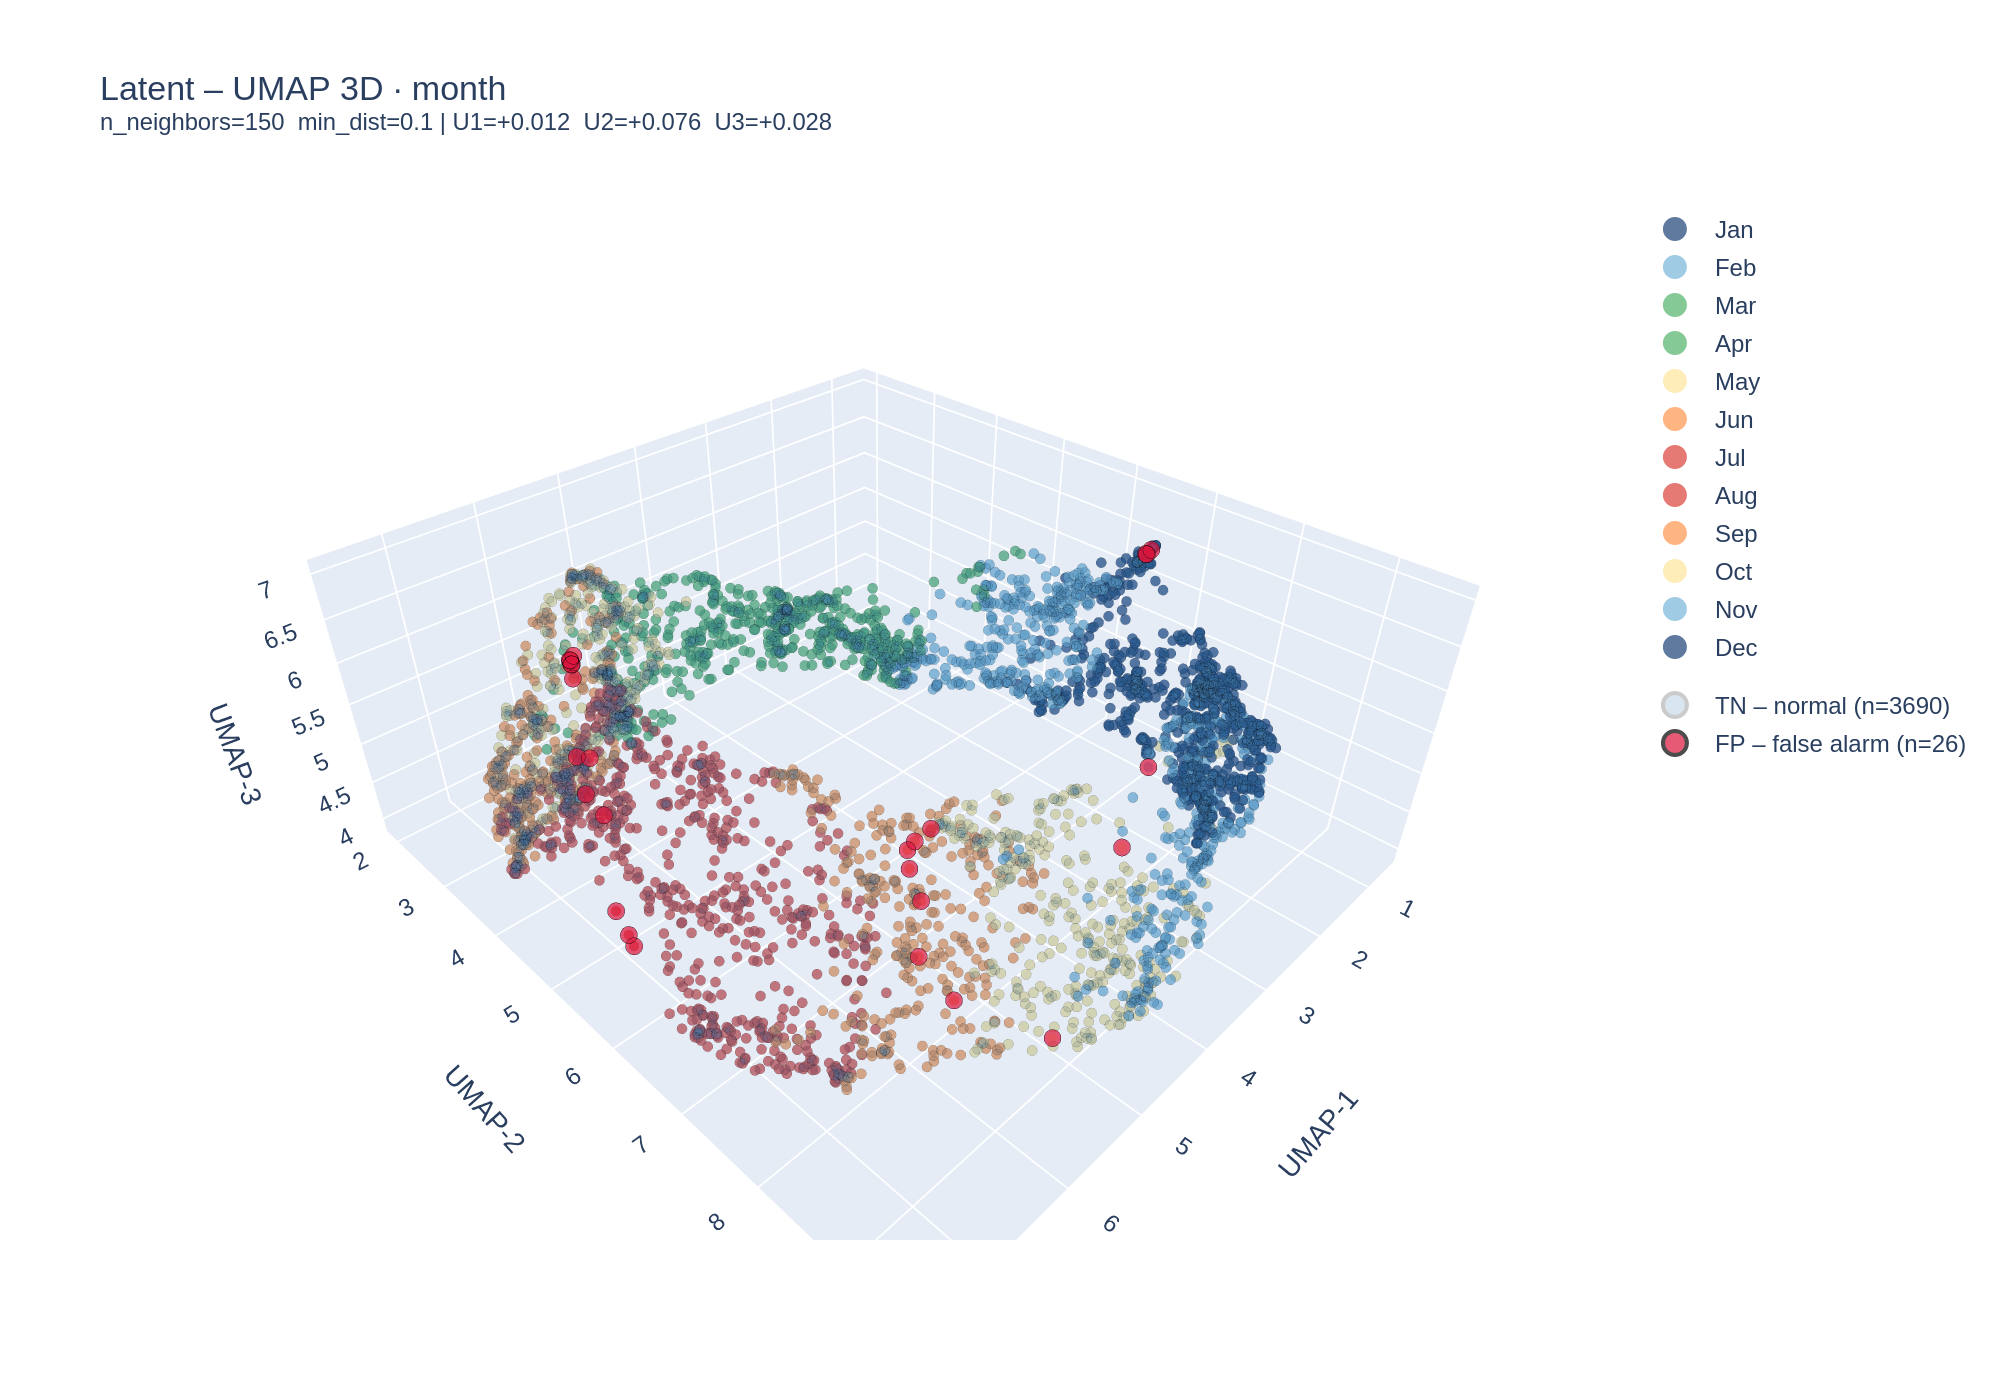

=== TF_VAE ===


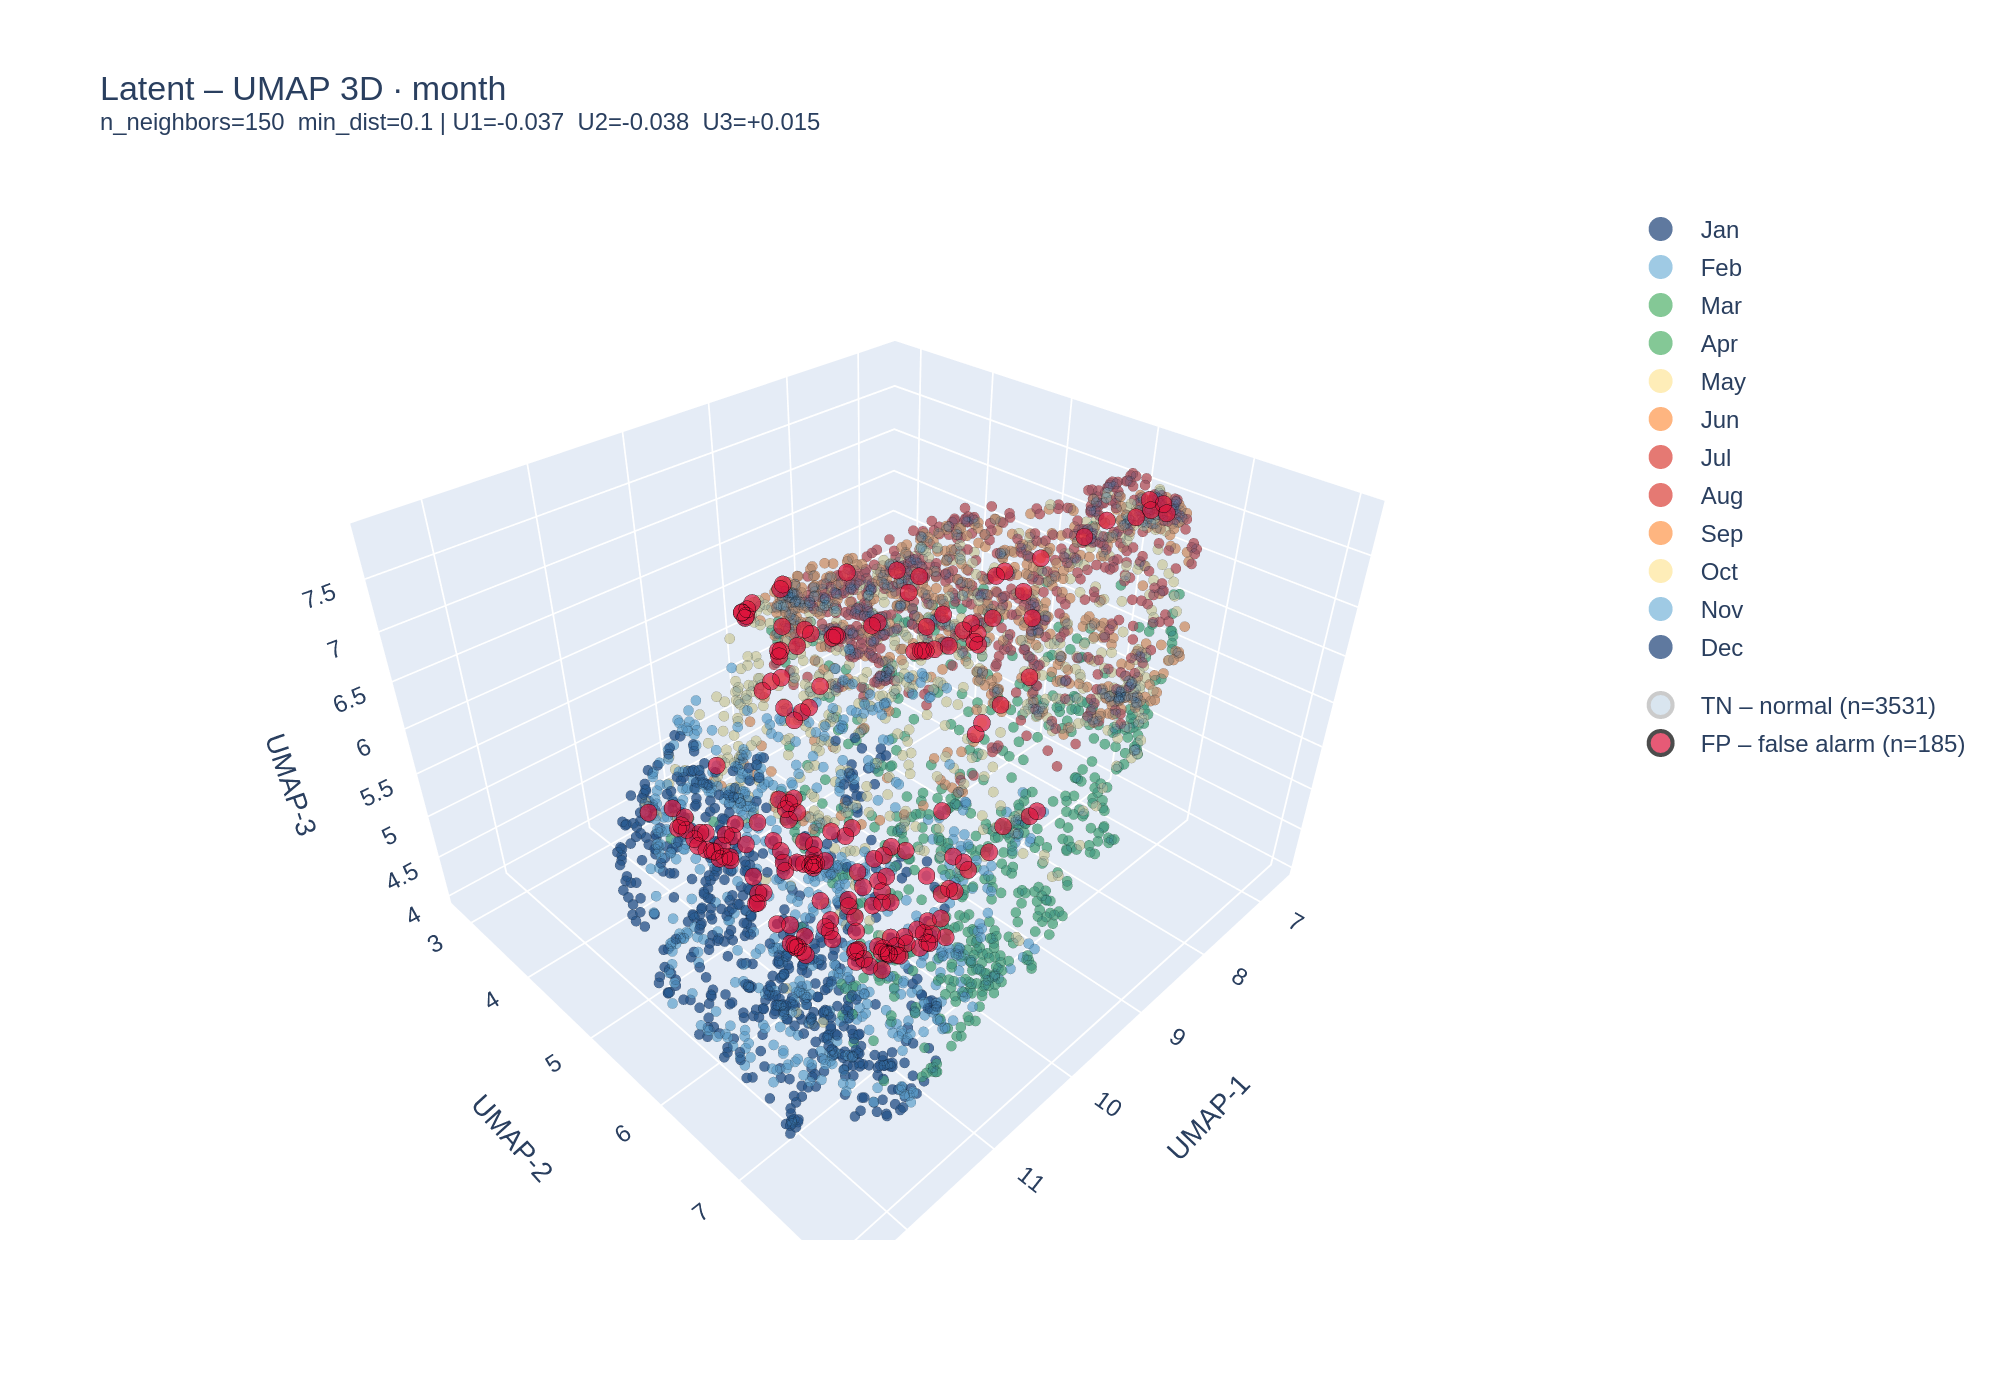

In [15]:
import sys
sys.path.insert(0, "scripts")
from pathlib import Path
from plot_latent_umap import find_trial_dirs
from IPython.display import Image, display

# Only the month-colored plot is shown, to keep this section manageable
# across 4 architectures — hour-of-day and day-of-year are also generated
# by the command above if you want to check them yourself.
for _trial_dir in find_trial_dirs(FULL_SESSION_DIR):
    _arch = Path(_trial_dir).parts[-3]  # .../Clean/<Arch>/baseline_<Arch>/<hash>_seed_49
    print(f"=== {_arch} ===")
    display(Image(filename=f"{_trial_dir}/latent_umap_month.png"))

In [16]:
import sys
sys.path.insert(0, "scripts")
from pathlib import Path
from plot_latent_umap import find_trial_dirs
from IPython.display import HTML, display

# Interactive version — only attempted in Colab (IN_COLAB, set when this
# notebook cloned the repo above). It depends on loading Plotly's JS from an
# external CDN, which GitHub's and VS Code's notebook previews block, so it
# would render as nothing there even though the file is saved correctly.
# Only the month-colored plot is shown, to keep this section manageable.
if IN_COLAB:
    for _trial_dir in find_trial_dirs(FULL_SESSION_DIR):
        _arch = Path(_trial_dir).parts[-3]  # .../Clean/<Arch>/baseline_<Arch>/<hash>_seed_49
        print(f"=== {_arch} ===")
        with open(f"{_trial_dir}/latent_umap_month.html", encoding="utf-8") as _f:
            display(HTML(_f.read()))

Found 4 trial directories under runs/trials_suite/case01_clean_baseline_full
=== LSTM ===


=== MLP ===


=== MLP_Cyclic ===


=== TF_VAE ===


## Scope of this testcase

This notebook runs `case01_clean_baseline_suite.yaml` at three dataset scales and compares the results directly, to make an otherwise-invisible dependency explicit: conclusions about any one architecture's false-positive calibration depend on evaluating it with enough warmup data. Single seed at each scale (real hardware nondeterminism applies), so exact FPR values shouldn't be over-interpreted from one seed per scale — the qualitative per-architecture trend is the intended takeaway.

The mini datasets are Colab-portable; the full-scale split files also ship with the repo (`data/era5/full_scale/split/`), so this notebook works out of the box end to end, just slower for the full-scale step. See `DATA_LICENSE.md` for exact provenance of all three scales.

This is a compact demonstration, not a full reproduction of every result reported in the thesis (single seed, this repo's own port of the training code).

### Download all three dataset-scale runs in this notebook

Off by default — see the cell below to enable it.

In [13]:
# Set to True and re-run this cell to download a zip of all three
# dataset-scale run directories in this notebook (MINI28_SESSION_DIR,
# MINI50_SESSION_DIR, FULL_SESSION_DIR). SESSION_ROOT itself is never
# created as a directory -- it's only used as a naming prefix for the
# three real ones, each named <SESSION_ROOT>_<label> -- so this zips
# each of the three real directories into one combined archive instead.
DOWNLOAD_RUN_DIR = False

import os
import zipfile

if not DOWNLOAD_RUN_DIR:
    print(
        "Run directories not downloaded (DOWNLOAD_RUN_DIR=False). "
        "To download them, set DOWNLOAD_RUN_DIR = True above and re-run this cell."
    )
else:
    from google.colab import files

    session_dirs = {
        "mini_28pct": MINI28_SESSION_DIR,
        "mini_50pct": MINI50_SESSION_DIR,
        "full": FULL_SESSION_DIR,
    }
    archive_path = f"{SESSION_ROOT.rstrip('/').replace('/', '_')}.zip"
    with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for label, session_dir in session_dirs.items():
            for root, _, filenames in os.walk(session_dir):
                for filename in filenames:
                    file_path = os.path.join(root, filename)
                    arcname = os.path.join(label, os.path.relpath(file_path, session_dir))
                    zf.write(file_path, arcname)
    print(f"Zipped {list(session_dirs.values())} -> {archive_path}")
    files.download(archive_path)

Run directories not downloaded (DOWNLOAD_RUN_DIR=False). To download them, set DOWNLOAD_RUN_DIR = True above and re-run this cell.
